In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Explore The Dataset

In [4]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/star_classification.csv'
df = pd.read_csv(file_path)

print(df.head())

         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   5812  56354       171  
1  GALAXY  0.77913

#Check for missing data / Duplicates

In [5]:
df.info()
print("nMissing values per column:")
print(df.isna().sum())
print("nDuplicated rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

#Explore Descriptive Statistics

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


#Descriptive: whats the current Stellar Body Distribution


/tmp/ipykernel_5842/3537175498.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


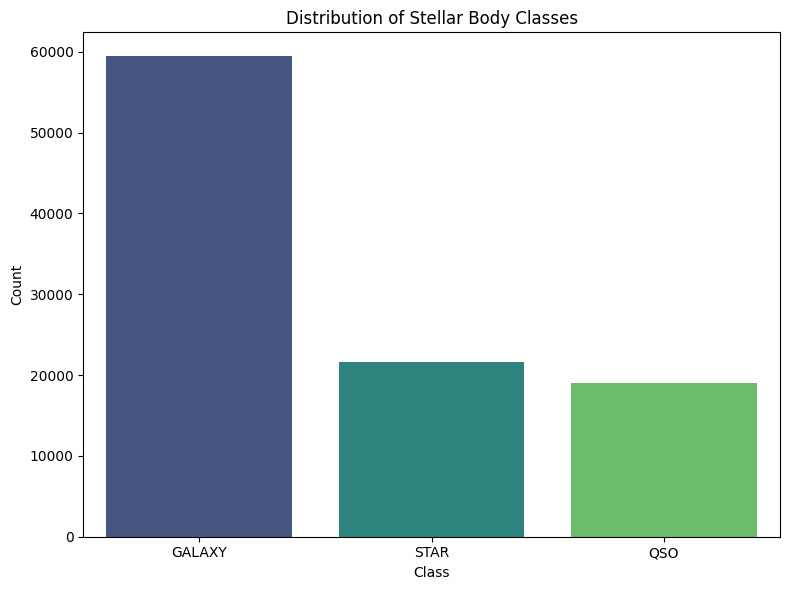

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset to define 'df'
file_path = '/content/drive/MyDrive/Colab Notebooks/star_classification.csv'
df = pd.read_csv(file_path)

# Count the occurrences of each class
class_counts = df['class'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Stellar Body Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#Disbribution of the photometric bands

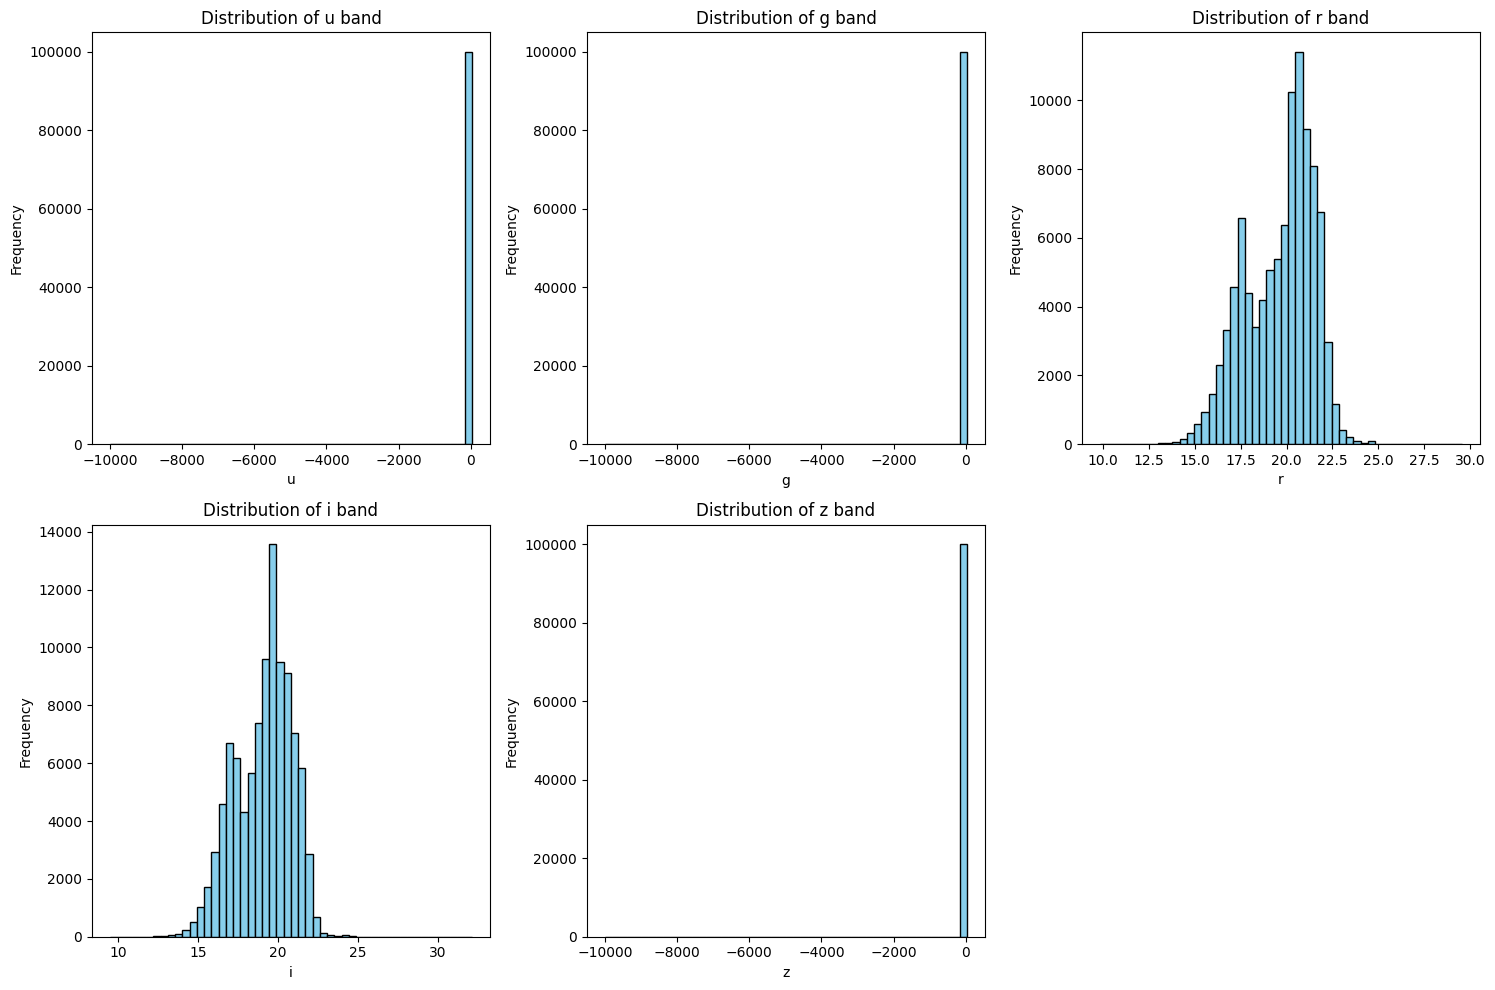

In [8]:
import matplotlib.pyplot as plt

bands = ['u', 'g', 'r', 'i', 'z']

plt.figure(figsize=(15, 10))
for i, band in enumerate(bands):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[band], bins=50, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {band} band')
    plt.xlabel(band)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#check the correlation of feeatures

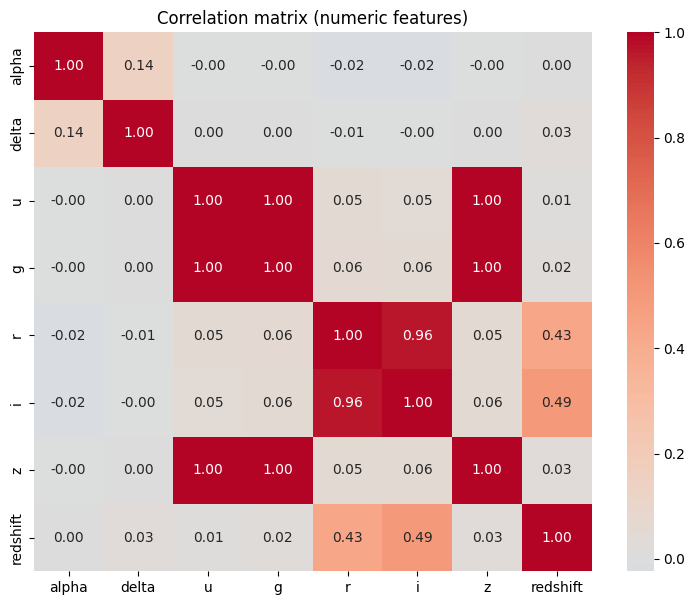

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Drop ID-like columns before correlating — they're arbitrary numbers, not signals
id_like = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
           'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
numeric_df = df.drop(columns=id_like).select_dtypes(include=np.number)

plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()

#Feature Engineering

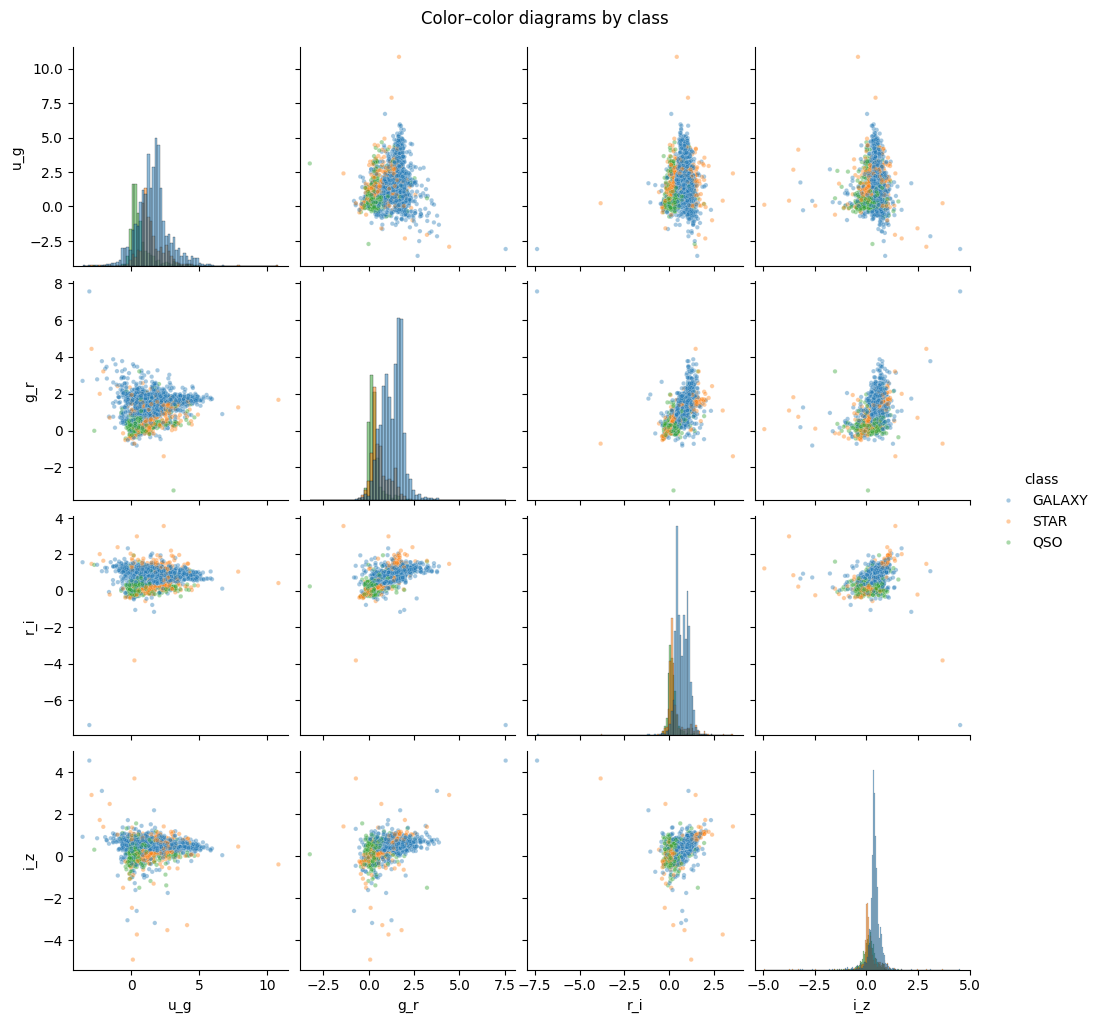

In [10]:

df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']


sample = df.sample(3000, random_state=42)

sns.pairplot(sample, vars=['u_g', 'g_r', 'r_i', 'i_z'],
             hue='class', diag_kind='hist', plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle("Color–color diagrams by class", y=1.02)
plt.show()

#Logistic Regression classifier-Red shift removed

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop bookkeeping columns — they're IDs, not real signal
id_like = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
           'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df_model = df.drop(columns=id_like)

# Build the color features (differences between adjacent bands)
df_model['u_g'] = df_model['u'] - df_model['g']
df_model['g_r'] = df_model['g'] - df_model['r']
df_model['r_i'] = df_model['r'] - df_model['i']
df_model['i_z'] = df_model['i'] - df_model['z']

# Separate features (X) from target (y)
# Deliberately EXCLUDE redshift for now — we want to see how the model does without the "cheat" feature
feature_cols = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z', 'alpha', 'delta']
X = df_model[feature_cols]
y = df_model['class']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True).round(3))

Features shape: (100000, 11)
Target distribution:
 class
GALAXY    0.594
STAR      0.216
QSO       0.190
Name: proportion, dtype: float64


#Train Test Split (80% Train 20% Test)

In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (80000, 11)  Test size: (20000, 11)


In [13]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LogisticRegression


logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

print("Training accuracy:", round(logreg.score(X_train_scaled, y_train), 4))
print("Test accuracy:    ", round(logreg.score(X_test_scaled, y_test), 4))

Training accuracy: 0.7619
Test accuracy:     0.7587


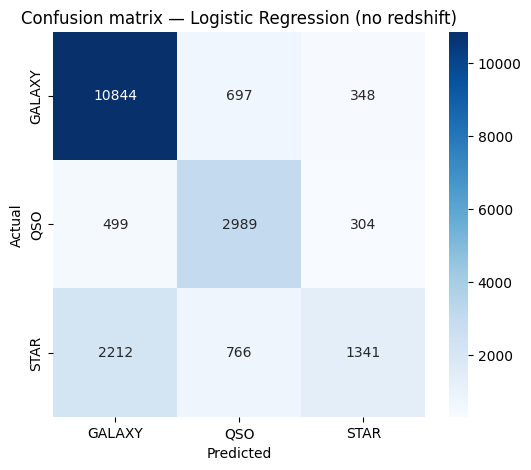


Classification report:
              precision    recall  f1-score   support

      GALAXY       0.80      0.91      0.85     11889
         QSO       0.67      0.79      0.73      3792
        STAR       0.67      0.31      0.42      4319

    accuracy                           0.76     20000
   macro avg       0.71      0.67      0.67     20000
weighted avg       0.75      0.76      0.74     20000



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = logreg.predict(X_test_scaled)

# Confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred, labels=logreg.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=logreg.classes_, yticklabels=logreg.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — Logistic Regression (no redshift)")
plt.show()

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Model coefficients:
              u       g      r      i      z    u_g     g_r    r_i    i_z  \
GALAXY  13.397  13.414 -0.701 -0.796 -2.995 -0.286  13.472  0.196  2.959   
QSO     -7.728  -7.720  0.563  0.692  3.083 -0.349  -7.762 -0.343 -3.053   
STAR    -5.670  -5.694  0.138  0.103 -0.089  0.635  -5.710  0.148  0.094   

        alpha  delta  
GALAXY -0.017 -0.092  
QSO     0.062  0.136  
STAR   -0.044 -0.044  


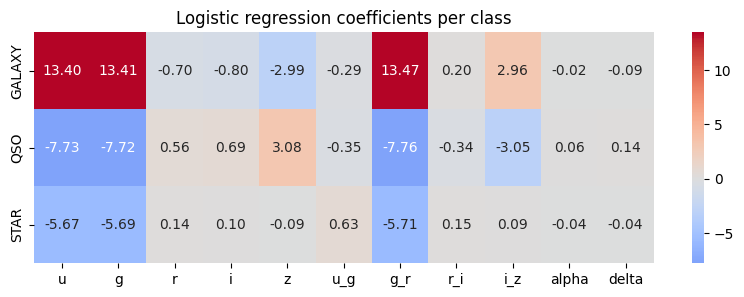

In [16]:
import pandas as pd

# Coefficients: one row per class, one column per feature
coefs = pd.DataFrame(logreg.coef_, columns=feature_cols, index=logreg.classes_)
print("Model coefficients:\n", coefs.round(3))

# Visualize as a heatmap for readability
plt.figure(figsize=(10, 3))
sns.heatmap(coefs, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Logistic regression coefficients per class")
plt.show()

#Remove redshift Logistic

In [17]:

feature_cols_with_z = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z',
                       'alpha', 'delta', 'redshift']
X_z = df_model[feature_cols_with_z]
y_z = df_model['class']

# Same split settings as before — random_state=42 keeps it comparable
X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(
    X_z, y_z, test_size=0.2, random_state=42, stratify=y_z
)

# Fit a fresh scaler on this feature set
scaler_z = StandardScaler()
X_train_z_scaled = scaler_z.fit_transform(X_train_z)
X_test_z_scaled = scaler_z.transform(X_test_z)

In [18]:
logreg_z = LogisticRegression(max_iter=1000, random_state=42)
logreg_z.fit(X_train_z_scaled, y_train_z)

print("WITHOUT redshift → Test accuracy:", round(logreg.score(X_test_scaled, y_test), 4))
print("WITH redshift    → Test accuracy:", round(logreg_z.score(X_test_z_scaled, y_test_z), 4))

WITHOUT redshift → Test accuracy: 0.7587
WITH redshift    → Test accuracy: 0.9563


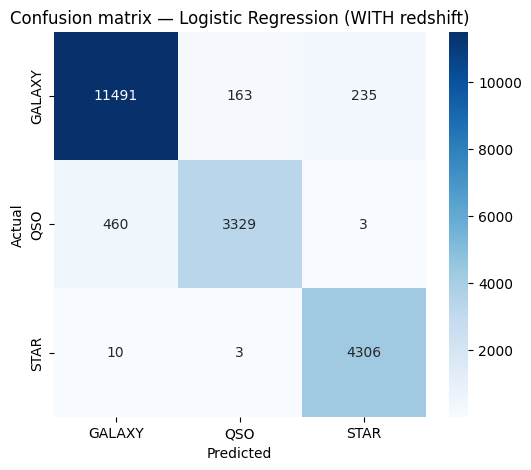


Classification report (with redshift):
              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.96     11889
         QSO       0.95      0.88      0.91      3792
        STAR       0.95      1.00      0.97      4319

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000



In [19]:
y_pred_z = logreg_z.predict(X_test_z_scaled)

cm_z = confusion_matrix(y_test_z, y_pred_z, labels=logreg_z.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_z, annot=True, fmt='d', cmap='Blues',
            xticklabels=logreg_z.classes_, yticklabels=logreg_z.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — Logistic Regression (WITH redshift)")
plt.show()

print("\nClassification report (with redshift):")
print(classification_report(y_test_z, y_pred_z))

#Redshift Included

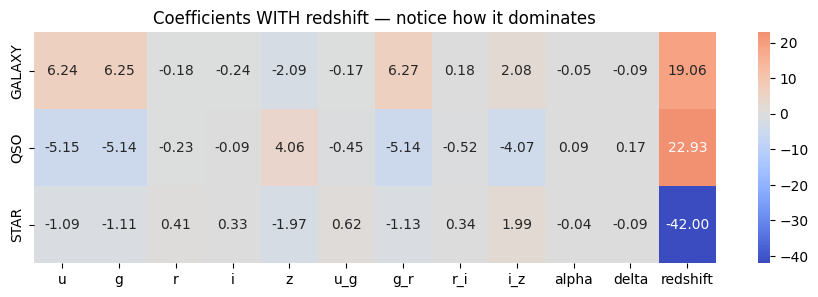

In [20]:
coefs_z = pd.DataFrame(logreg_z.coef_, columns=feature_cols_with_z, index=logreg_z.classes_)

plt.figure(figsize=(11, 3))
sns.heatmap(coefs_z, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Coefficients WITH redshift — notice how it dominates")
plt.show()

#Random Forrest Algorithm

In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- Reload the raw data ---
file_path = '/content/drive/MyDrive/Colab Notebooks/star_classification.csv'
df = pd.read_csv(file_path)

# --- Drop bookkeeping columns ---
id_like = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
           'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df_model = df.drop(columns=id_like)

# --- Engineer color features ---
df_model['u_g'] = df_model['u'] - df_model['g']
df_model['g_r'] = df_model['g'] - df_model['r']
df_model['r_i'] = df_model['r'] - df_model['i']
df_model['i_z'] = df_model['i'] - df_model['z']

# --- Feature set WITHOUT redshift ---
feature_cols = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z', 'alpha', 'delta']
X = df_model[feature_cols]
y = df_model['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Train Random Forest (no redshift) ---
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(f"Random Forest (no redshift) → Test accuracy: {rf.score(X_test, y_test):.4f}")

Random Forest (no redshift) → Test accuracy: 0.8892


In [22]:
# --- Feature set WITH redshift ---
feature_cols_with_z = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z',
                       'alpha', 'delta', 'redshift']
X_z = df_model[feature_cols_with_z]
y_z = df_model['class']

X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(
    X_z, y_z, test_size=0.2, random_state=42, stratify=y_z
)

# --- Train Random Forest (with redshift) ---
rf_z = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_z.fit(X_train_z, y_train_z)

print(f"Random Forest (with redshift) → Test accuracy: {rf_z.score(X_test_z, y_test_z):.4f}")

Random Forest (with redshift) → Test accuracy: 0.9799


#Random Forrest with Red Shift

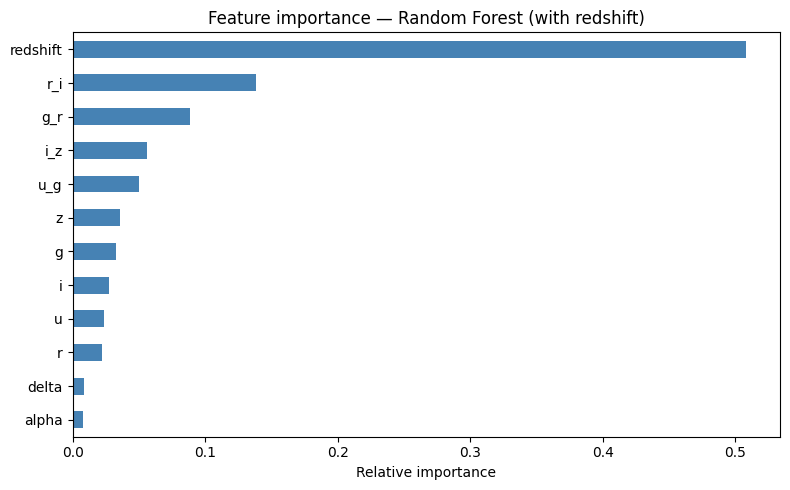


Top 3 features:
redshift    0.508220
r_i         0.138550
g_r         0.088396
dtype: float64


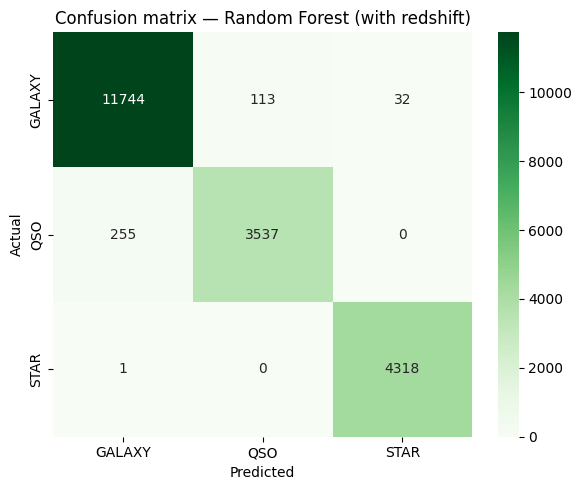


Classification report:
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000



In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- Feature importance ---
importances = pd.Series(rf_z.feature_importances_, index=feature_cols_with_z)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title("Feature importance — Random Forest (with redshift)")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.show()

print("\nTop 3 features:")
print(importances.sort_values(ascending=False).head(3))

# --- Confusion matrix ---
y_pred_rf_z = rf_z.predict(X_test_z)
cm_rf = confusion_matrix(y_test_z, y_pred_rf_z, labels=rf_z.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=rf_z.classes_, yticklabels=rf_z.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix — Random Forest (with redshift)")
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_test_z, y_pred_rf_z))

#Compare multiple models

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score

# Reload
file_path = '/content/drive/MyDrive/Colab Notebooks/star_classification.csv'
df = pd.read_csv(file_path)

# Drop bookkeeping columns
id_like = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
           'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
df_model = df.drop(columns=id_like)

# Color features
df_model['u_g'] = df_model['u'] - df_model['g']
df_model['g_r'] = df_model['g'] - df_model['r']
df_model['r_i'] = df_model['r'] - df_model['i']
df_model['i_z'] = df_model['i'] - df_model['z']

# Feature set with redshift (for the bake-off)
feature_cols_with_z = ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z',
                       'alpha', 'delta', 'redshift']
X = df_model[feature_cols_with_z]
y = df_model['class']

print("Shape:", X.shape)

Shape: (100000, 12)


#Multi-Model Test (Not Auto ML)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time


models = {
    'Logistic Regression':  Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'K-Nearest Neighbors':  Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))]),
    'Naive Bayes':          GaussianNB(),
    'Decision Tree':        DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=1),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
}

# Run 5-fold cross-validation for each model
# CV means "train on 4/5 of the data, test on the other 1/5, repeat 5 times, average the score"
# This is more robust than a single train/test split — it protects against getting lucky with the split
results = []
for name, model in models.items():
    start = time.time()
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy', n_jobs=1)
    elapsed = time.time() - start
    results.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std Dev': scores.std(),
        'Time (s)': elapsed
    })
    print(f"{name:25s}  Acc: {scores.mean():.4f} \u00b1 {scores.std():.4f}  ({elapsed:.1f}s)")

# Build a leaderboard sorted by accuracy
leaderboard = pd.DataFrame(results).sort_values('Mean Accuracy', ascending=False).reset_index(drop=True)
print("\n=== LEADERBOARD ===")
print(leaderboard.to_string(index=False))

Logistic Regression        Acc: 0.9554 ± 0.0018  (10.7s)
K-Nearest Neighbors        Acc: 0.9436 ± 0.0014  (13.1s)
Naive Bayes                Acc: 0.7621 ± 0.0809  (0.6s)
Decision Tree              Acc: 0.9663 ± 0.0018  (14.3s)
Random Forest              Acc: 0.9791 ± 0.0009  (403.0s)
Extra Trees                Acc: 0.9741 ± 0.0008  (56.0s)
Gradient Boosting          Acc: 0.9775 ± 0.0007  (777.5s)

=== LEADERBOARD ===
              Model  Mean Accuracy  Std Dev   Time (s)
      Random Forest        0.97910 0.000883 403.042417
  Gradient Boosting        0.97753 0.000696 777.525092
        Extra Trees        0.97409 0.000840  55.970973
      Decision Tree        0.96634 0.001819  14.280331
Logistic Regression        0.95536 0.001793  10.693183
K-Nearest Neighbors        0.94360 0.001445  13.131705
        Naive Bayes        0.76207 0.080872   0.576323


#Leaderboard of models

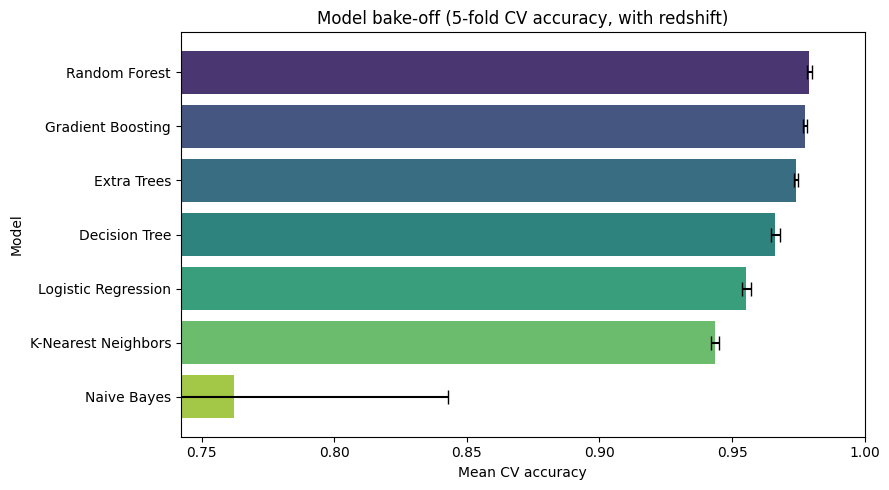

In [26]:
import numpy as np

plt.figure(figsize=(9, 5))
# Plot bars without error bars. Ensure the order matches the leaderboard DataFrame.
ax = sns.barplot(data=leaderboard, y='Model', x='Mean Accuracy',
                 palette='viridis', errorbar=None, order=leaderboard['Model'],
                 hue='Model', legend=False)

# Get the y-coordinates of the center of each bar
y_centers = [patch.get_y() + patch.get_height() / 2 for patch in ax.patches]

# Add pre-computed error bars manually using plt.errorbar
ax.errorbar(x=leaderboard['Mean Accuracy'], y=y_centers, xerr=leaderboard['Std Dev'],
            fmt='none', color='black', capsize=5)

plt.xlim(leaderboard['Mean Accuracy'].min() - 0.02, 1.0)
plt.title("Model bake-off (5-fold CV accuracy, with redshift)")
plt.xlabel("Mean CV accuracy")
plt.tight_layout()
plt.show()